<a href="https://colab.research.google.com/github/mutallimovaydin/ecommerce_customer_segmentation_unsupervised_rfm/blob/main/online_retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. DATASET OVERVİEW**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [ ]:
!unzip online+retail.zip

Archive:  online+retail.zip
 extracting: Online Retail.xlsx      


In [ ]:
df = pd.read_excel("Online Retail.xlsx")

In [ ]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,17850.000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,17850.000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,17850.000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,17850.000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,17850.000,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


**2. DATA CLEANING**

In [ ]:
df_clean = df.dropna(subset=['CustomerID']).copy()

In [ ]:
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]

In [ ]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

In [ ]:
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [ ]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [ ]:
print(f"\nTemizlenmish datanın olchusu: {df_clean.shape}")


Temizlenmish datanın olchusu: (397884, 9)


In [ ]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalSum,0


**3. RFM  FEATURE ENGİNEERİNG**

In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [ ]:
import datetime as dt
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

In [ ]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: Son alish-verishden kechen gun
    'InvoiceNo': 'nunique',                                   # Frequency: Unikal hesab-faktura (sifarish) sayı
    'TotalSum': 'sum'                                         # Monetary: Umumi xerclenen mebleg
})

In [ ]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

In [ ]:
display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.600
12347,2,7,4310.000
12348,75,4,1797.240
12349,19,1,1757.550
12350,310,1,334.400


**4. FEATURE PREPARATİON**

In [ ]:
# Logaritmik transformasiya (0 dəyərlərini idarə etmək üçün log1p istifadə edirik). Bunu bilmirdim süni intellekt vasitəsilə öyrəndim
rfm_log = np.log1p(rfm)

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(rfm_scaled_array, index=rfm.index, columns=rfm.columns)

display(rfm_scaled.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.462,-0.955,3.706
12347,-2.039,1.074,1.412
12348,0.373,0.386,0.716
12349,-0.623,-0.955,0.699
12350,1.425,-0.955,-0.619


**5. Clustering and Comparison**

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=10)
dbscan_labels = dbscan.fit_predict(rfm_scaled)
rfm_scaled['Outlier_DBSCAN'] = dbscan_labels
outliers_count = (dbscan_labels == -1).sum()
print(f"DBSCAN ile tapılan kenar deyer (noise) sayı: {outliers_count}")
rfm_scaled_clean = rfm_scaled[rfm_scaled['Outlier_DBSCAN'] != -1].drop(columns=['Outlier_DBSCAN'])
rfm_clean = rfm[rfm_scaled['Outlier_DBSCAN'] != -1]

DBSCAN ile tapılan kenar deyer (noise) sayı: 50


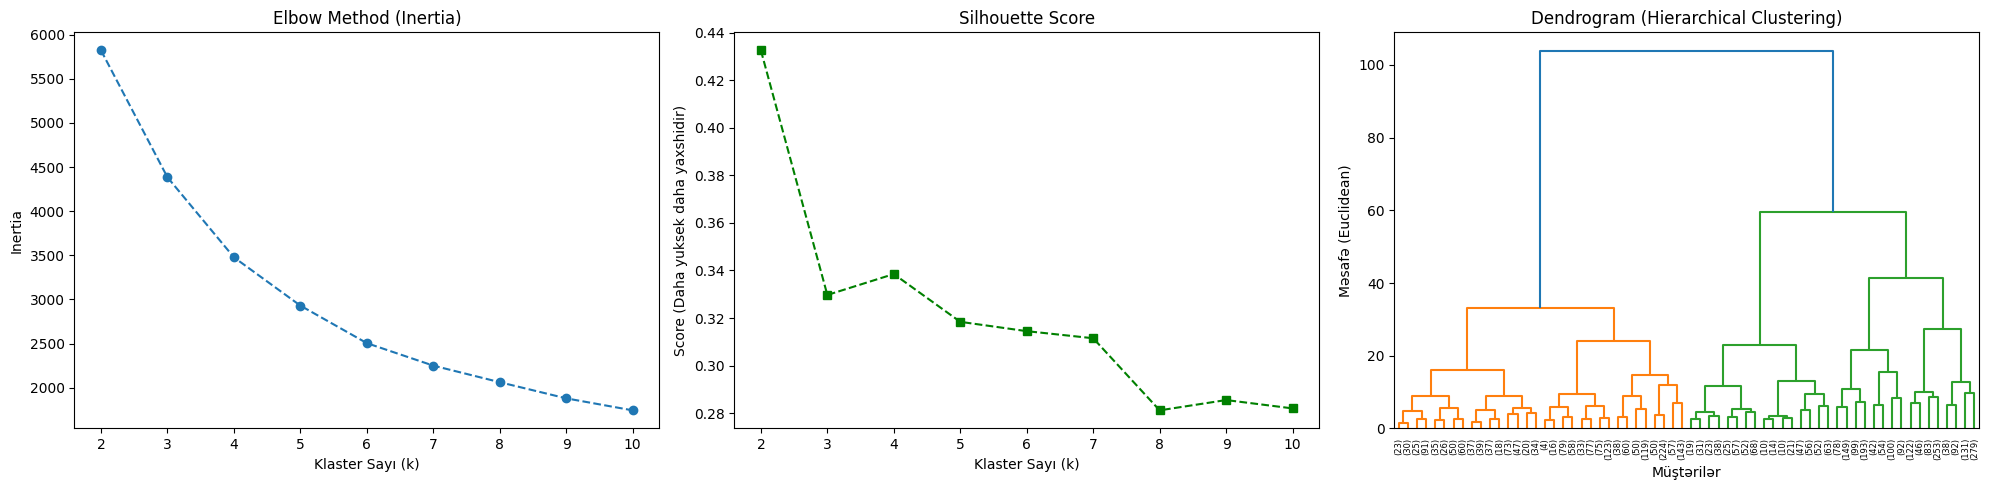

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc

inertia = []
silhouette_scores = []
k_range = range(2, 11)

# K-Means üçün 2-dən 10-a qədər k dəyərlərini yoxlayırıq
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_clean)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled_clean, kmeans.labels_))

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# 1. Elbow Method Graph
ax[0].plot(k_range, inertia, marker='o', linestyle='--')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('Klaster Sayı (k)')
ax[0].set_ylabel('Inertia')

# 2. Silhouette Score Graph
ax[1].plot(k_range, silhouette_scores, marker='s', color='green', linestyle='--')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Klaster Sayı (k)')
ax[1].set_ylabel('Score (Daha yuksek daha yaxshidir)')

# 3. Hierarchical Clustering (Dendrogram)
ax[2].set_title("Dendrogram (Hierarchical Clustering)")
# Ward metodu ilə dendrogram qururuq (hesablama vaxt ala bilər)(Süni intellekt-dən öyrəndim bunu)
dend = shc.dendrogram(shc.linkage(rfm_scaled_clean, method='ward'), ax=ax[2], truncate_mode='level', p=5)
ax[2].set_xlabel('Müştərilər')
ax[2].set_ylabel('Məsafə (Euclidean)')

plt.tight_layout()
plt.show()

,Recency_Median,Frequency_Median,Monetary_Median,Customer_Count
Cluster,,,,
0,19.000,2.000,423.900,827
1,60.000,4.000,1240.100,1149
2,9.000,9.000,3110.000,803
3,185.000,1.000,290.000,1509


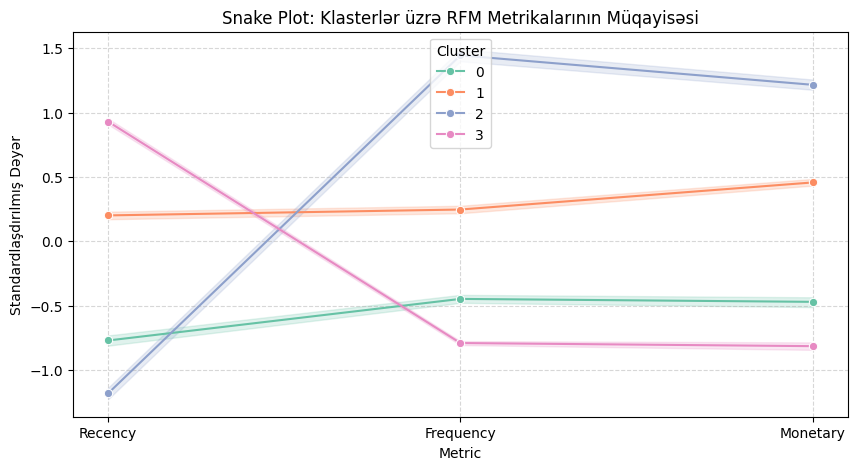

In [ ]:
from sklearn.decomposition import PCA

k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled_clean)
rfm_scaled_clean['Cluster'] = cluster_labels
rfm_clean['Cluster'] = cluster_labels
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(rfm_scaled_clean.drop(columns=['Cluster']))
rfm_pca = pd.DataFrame(pca_transformed, columns=['PC1', 'PC2'], index=rfm_clean.index)
rfm_pca['Cluster'] = cluster_labels.astype(str)

# Interaktiv Scatter Plot
fig = px.scatter(
    rfm_pca, x='PC1', y='PC2', color='Cluster',
    title='PCA ilə 2D Müştəri Seqmentləri',
    hover_data={'PC1': False, 'PC2': False, 'Cluster': True},
    color_discrete_sequence=px.colors.qualitative.Set2,
    template='plotly_white'
)
fig.show()

# 3. Seqmentlerin Profil Statistikası (Median ve Sayı)
cluster_summary = rfm_clean.groupby('Cluster').agg({
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': ['median', 'count']
}).round(1)

# Sutun adlarini seliqeye saliriq
cluster_summary.columns = ['Recency_Median', 'Frequency_Median', 'Monetary_Median', 'Customer_Count']
display(cluster_summary)

# 4. Snake Plot (Klasterlerin Muqayiseli Qrafiki)
rfm_melted = pd.melt(
    rfm_scaled_clean.reset_index(),
    id_vars=['CustomerID', 'Cluster'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metric',
    value_name='Scaled_Value'
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=rfm_melted, x='Metric', y='Scaled_Value', hue='Cluster', palette='Set2', marker='o')
plt.title('Snake Plot: Klasterlər üzrə RFM Metrikalarının Müqayisəsi')
plt.ylabel('Standardlaşdırılmış Dəyər')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()